# 9. Full Pipeline Cookbook: M 13

In this User Guide Cookbook, you will learn how to process a single target (M 13) through all the available pipelines in a single workflow. 

This notebook serves as a quick reference for running the full Astrometrics pipeline end-to-end, skipping the deep explanatory text found in the earlier modular guides.

You will see how to:
1. Initialize the `Astrometrics` high-level interface.
2. Stack and calibrate raw images.
3. Perform astrometry and plate-solving.
4. Run differential photometry.
5. Extract 1D spectra.



In [1]:
from astrometricslib import Astrometrics

astrometrics = Astrometrics()
target = astrometrics.targets.get("M 13")
if target:
    print(f"Loaded target '{target.id}' with {len(target.frames)} registered frames.")

Loaded target 'M 13' with 147 registered frames.


## 2. Inspecting & Filtering Frame Records by Camera and Filter

We filter frame records to segregate Luminance (`L`) frames, Slitless Spectroscopy (`SPEC`) frames, and DSLR exposures.

In [2]:
cameras = {frame.camera for frame in target.frames}
filters = {frame.filter for frame in target.frames}
print(f"Target '{target.id}' Camera Models: {cameras}")
print(f"Target '{target.id}' Filter Types: {filters}\n")

luminance_frames = [
    frame
    for frame in target.frames
    if frame.camera == "ZWO ASI 533MM Pro" and str(frame.filter).upper() in ("L", "LUMINANCE")
]
spectroscopy_frames = [
    frame for frame in target.frames if str(frame.filter).upper() in ("SPEC", "STAR ANALYZER 200")
]
nikon_frames = [frame for frame in target.frames if frame.camera == "Nikon DSLR DSC D5300"]

print(f"Luminance frames: {len(luminance_frames)}")
print(f"Spectroscopy frames: {len(spectroscopy_frames)}")
print(f"Nikon DSLR frames: {len(nikon_frames)}")

Target 'M 13' Camera Models: {'Nikon DSLR DSC D5300', 'ZWO ASI 533MM Pro'}
Target 'M 13' Filter Types: {<FilterType.L: 'Luminance'>, <FilterType.NONE: 'None'>, <FilterType.SPEC: 'Star Analyzer 200'>}

Luminance frames: 46
Spectroscopy frames: 40
Nikon DSLR frames: 60


## 3. Stacking ZWO ASI 533MM Pro Luminance Frames (`stacked_image`)

We execute Chauvenet rejection stacking on the Luminance exposures using `astrometrics.processing.run_stacking`.

In [3]:
if target:
    print(f"Stacking Luminance frames for {target.id}...")
    stacked_image = astrometrics.processing.run_stacking(
        target,
        frames_to_stack=luminance_frames,
        filter_type="L",
    )
    print(f"Luminance master stack: {stacked_image}")

Background-homogeneity split detected for target 'M 13': {'low_group_count': 2, 'high_group_count': 44, 'low_group_median': 0.0, 'high_group_median': 320.0, 'gap': 300.0, 'gap_ratio': 4.6875}


Stacking Luminance frames for M 13...
Luminance master stack: /media/michael/OS/Users/macoe/Library/lights/M 13/M_13_L_Stacked.fits


## 4. Stacking Spectroscopy Frames (`stacked_spectral_target`)

We execute frame stacking on the slitless spectroscopy (`SPEC`) exposures using `astrometrics.processing.run_stacking`.

In [4]:
if target:
    print(f"Stacking Spectroscopy frames for {target.id}...")
    stacked_spectral_image = astrometrics.processing.run_stacking(
        target,
        frames_to_stack=spectroscopy_frames,
        filter_type="SPEC",
    )
    print(f"Spectroscopy master stack: {stacked_spectral_image}")

Stacking Spectroscopy frames for M 13...
Spectroscopy master stack: /media/michael/OS/Users/macoe/Library/lights/M 13/M_13_SPEC_Stacked.fits


## 5. Running Astrometry Analysis

We perform WCS plate solving and catalog cross-matching on the master Luminance image using `astrometrics.processing.run_astrometry`.

In [5]:
if target:
    print(f"Running astrometry plate-solving for {target.id}...")
    astrometry_result = astrometrics.processing.run_astrometry(
        target,
        filter_type="L",
    )
    print(f"Astrometry solved: {astrometry_result.get('wcs') is not None}")

Running astrometry plate-solving for M 13...


Astrometry solved: True


## 6. Running Photometry Analysis

We perform aperture photometry and ensemble calibration across the Luminance frame sequence using `astrometrics.processing.run_photometry`.

In [6]:
if target:
    print(f"Running ensemble photometry for {target.id}...")
    photometry_result = astrometrics.processing.run_photometry(
        target,
        filter_type="L",
        frames=luminance_frames,
        use_astrometry_seed=True,
    )
    print(f"Photometry status: {photometry_result.get('status')}")

Running ensemble photometry for M 13...


Photometry status: completed


## 7. Running Spectroscopy Analysis

We detect zero-order star centroids and extract calibrated 1D spectra from the dispersed spectral image using `astrometrics.processing.run_spectroscopy`.

In [7]:
if target:
    print(f"Running spectroscopy analysis for {target.id}...")
    spectroscopy_result = astrometrics.processing.run_spectroscopy(target)
    spectral_stars = spectroscopy_result.get("stellar_objects", [])
    print(f"Spectroscopy extracted {len(spectral_stars)} spectra.")

Running spectroscopy analysis for M 13...
Auto-detected angle for star at (2017.866271987111, 1444.5082130717558): 1.84 degrees
Spectroscopy extracted 10 spectra.


## 8. Querying Enriched Stellar Catalog

We list and inspect the solved stellar objects associated with target **M 13** via `astrometrics.stars.list_objects`.

In [8]:
if target:
    stellar_objects = [obj for obj in astrometrics.stars.list_objects() if target.id in obj.target_ids]
    print(f"Retrieved {len(stellar_objects)} stellar objects for target {target.id}.")
    if stellar_objects:
        sample_star = stellar_objects[0]
        print(f"Sample Star: ID={sample_star.id}, Name={sample_star.name}, Mag={sample_star.magnitude}")

Retrieved 209 stellar objects for target M 13.
Sample Star: ID=FIELD_J251.1038+37.3769, Name=FIELD_J251.1038+37.3769, Mag=


## 9. Visualizing Results with Interactive Dashboards

We visualize the comprehensive multi-modal analysis results using the high-level `astrometrics.visualization` tools.

### 9.1 Interactive Target Dashboard

The target dashboard displays the FITS image with astrometric star overlays alongside side panels for photometry and spectroscopy that update dynamically when clicking stars.

Rendering interactive target dashboard for M 13...


/tmp/ipykernel_102541/3176258910.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


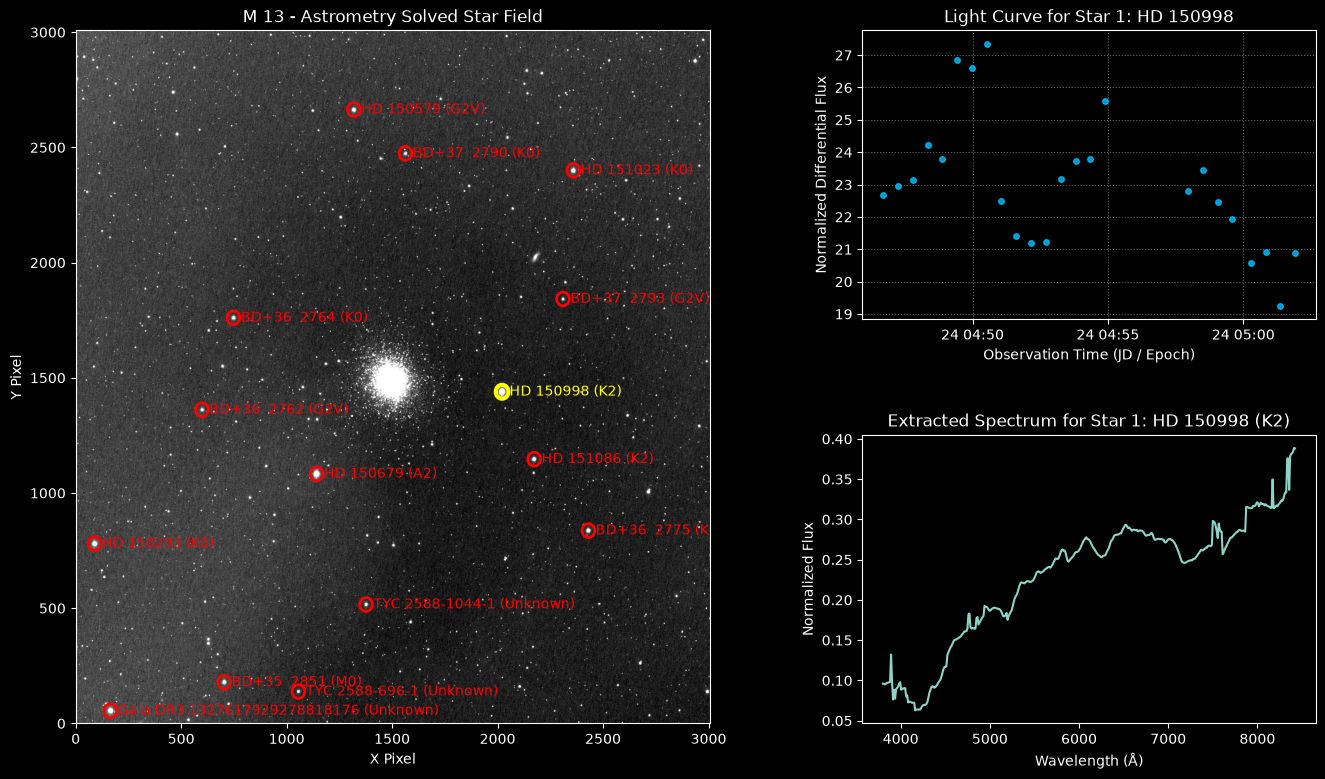

In [9]:
if target:
    print(f"Rendering interactive target dashboard for {target.id}...")
    figure = astrometrics.visualization.plot_target_dashboard(target)
    figure.show()

### 9.2 Star Multi-Modal Analysis Dashboard

The star dashboard displays a two-panel visualization for a single star showing its photometric light curve and calibrated 1D spectrum.

Rendering star dashboard for HD 150998...


/tmp/ipykernel_102541/2954733354.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  star_figure.show()


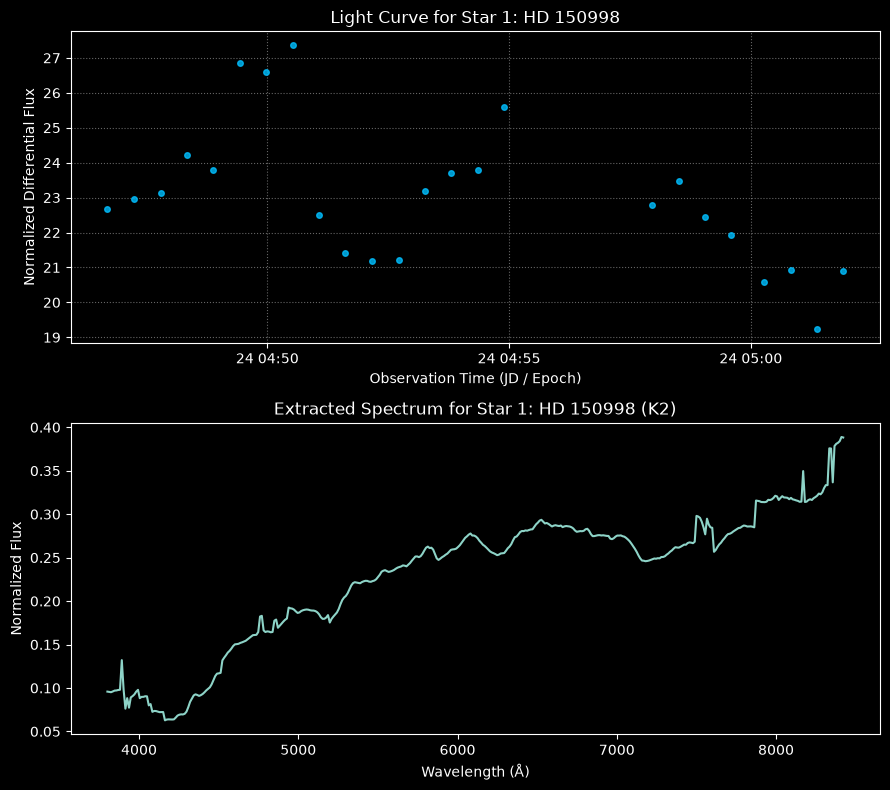

In [12]:
if target:
    selected_star = astrometrics.stars.get_object("HD 150998")
    spectral_star = astrometrics.stars.get_object(f"{selected_star.id}::spectroscopy")
    print(f"Rendering star dashboard for {selected_star.id}...")
    star_figure = astrometrics.visualization.plot_star_dashboard(selected_star, spectral_star=spectral_star)
    star_figure.show()

## Summary

You have learned how to:
1. Manage multi-camera and multi-filter datasets within a single target.
2. Execute Chauvenet rejection stacking for luminance and spectroscopy frames via `astrometrics.processing.run_stacking`.
3. Solve astrometry, extract photometry, and calibrate 1D spectra using explicit `astrometrics.processing.run_*` methods.
4. Inspect multi-modal results using `astrometrics.visualization.plot_target_dashboard` and `astrometrics.visualization.plot_star_dashboard`.